
# Decision Tree Regression


# 1. Import Libraries


In [1]:

import pandas as pd
import numpy as np

from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt



# 2. Create Dataset

Dataset:

| EXP | Gap | Salary |
|---|---|---|
| 2 | Yes | 40 |
| 2.5 | Yes | 42 |
| 3 | No | 52 |
| 4 | No | 60 |
| 4.5 | Yes | 56 |


In [2]:

data = {
    'EXP': [2, 2.5, 3, 4, 4.5],
    'Gap': ['Yes', 'Yes', 'No', 'No', 'Yes'],
    'Salary': [40, 42, 52, 60, 56]
}

df = pd.DataFrame(data)

df


,EXP,Gap,Salary
0,2.0,Yes,40
1,2.5,Yes,42
2,3.0,No,52
3,4.0,No,60
4,4.5,Yes,56



# 3. Encode Categorical Feature

Machine learning models cannot understand text directly.

So:

- Yes → 1
- No → 0


In [3]:

encoder = LabelEncoder()

df['Gap'] = encoder.fit_transform(df['Gap'])

df


,EXP,Gap,Salary
0,2.0,1,40
1,2.5,1,42
2,3.0,0,52
3,4.0,0,60
4,4.5,1,56



# 4. Separate Features and Target


In [4]:

X = df[['EXP', 'Gap']]
y = df['Salary']

print("Features:")
display(X)

print("\nTarget:")
display(y)


Features:


,EXP,Gap
0,2.0,1
1,2.5,1
2,3.0,0
3,4.0,0
4,4.5,1



Target:


,Salary
0,40
1,42
2,52
3,60
4,56



# 5. Train Decision Tree Regressor


In [5]:

model = DecisionTreeRegressor(random_state=42)

model.fit(X, y)

print("Model trained successfully.")


Model trained successfully.



# 6. Predictions


In [6]:

predictions = model.predict(X)

results = pd.DataFrame({
    'Actual Salary': y,
    'Predicted Salary': predictions
})

results


,Actual Salary,Predicted Salary
0,40,40.0
1,42,42.0
2,52,52.0
3,60,60.0
4,56,56.0



# 7. Predict New Data


In [7]:

# Example:
# EXP = 3.5
# Gap = No (0)

new_prediction = model.predict([[3.5, 0]])

print("Predicted Salary:", new_prediction[0])


Predicted Salary: 52.0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(



# 8. Visualize Decision Tree


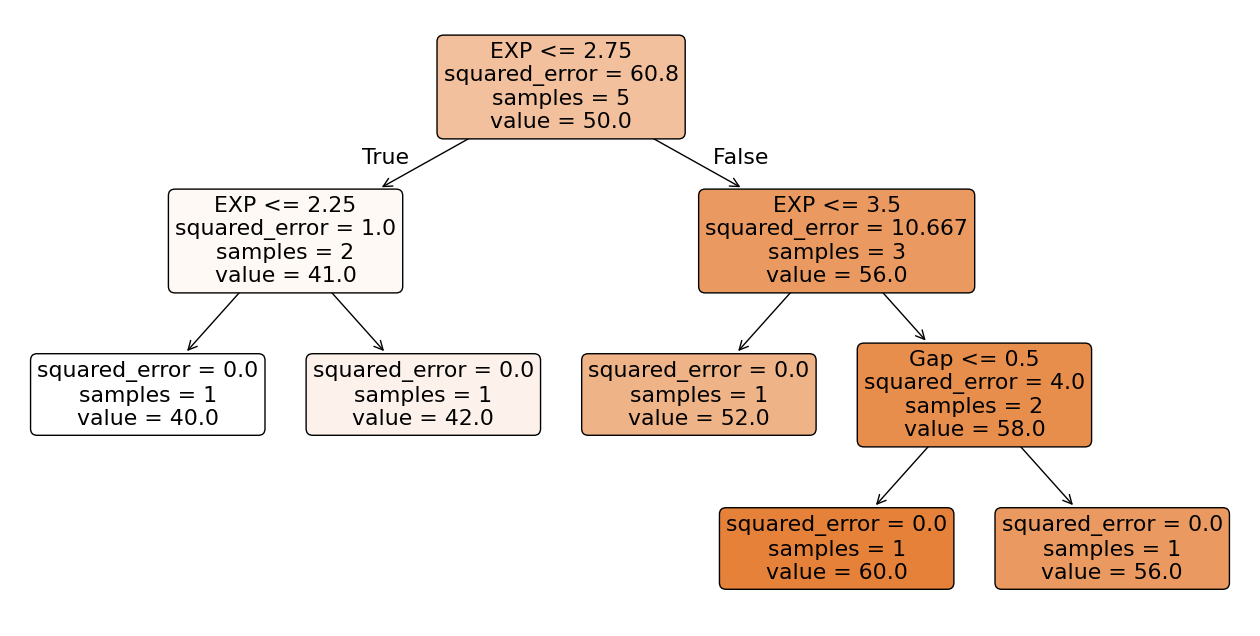

In [8]:

plt.figure(figsize=(16,8))

plot_tree(
    model,
    feature_names=['EXP', 'Gap'],
    filled=True,
    rounded=True
)

plt.show()



# 9. Feature Importance

This tells us which feature contributed more in reducing variance.


In [9]:

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance_df


,Feature,Importance
0,EXP,0.973684
1,Gap,0.026316



# 10. Evaluation Metrics


In [10]:

mae = mean_absolute_error(y, predictions)
mse = mean_squared_error(y, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y, predictions)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)


MAE : 0.0
MSE : 0.0
RMSE: 0.0
R2 Score: 1.0



# 11. Second Example — Hyperparameter Tuning

In real-world projects, we tune hyperparameters to avoid:

- Overfitting
- Underfitting

We will use:

- max_depth
- min_samples_split
- min_samples_leaf



# 12. Create Larger Dataset


In [11]:

data2 = {
    'Experience': [1,2,3,4,5,6,7,8,9,10,11,12],
    'Projects': [1,2,2,3,3,4,5,5,6,7,8,9],
    'Salary': [25,30,35,45,50,55,65,70,80,90,100,110]
}

df2 = pd.DataFrame(data2)

df2


,Experience,Projects,Salary
0,1,1,25
1,2,2,30
2,3,2,35
3,4,3,45
4,5,3,50
5,6,4,55
6,7,5,65
7,8,5,70
8,9,6,80
9,10,7,90



# 13. Train-Test Split


In [12]:

X2 = df2[['Experience', 'Projects']]
y2 = df2['Salary']

X_train, X_test, y_train, y_test = train_test_split(
    X2, y2,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape :", X_test.shape)


Training Shape: (9, 2)
Testing Shape : (3, 2)



# 14. Train Default Model


In [13]:

default_model = DecisionTreeRegressor(random_state=42)

default_model.fit(X_train, y_train)

default_predictions = default_model.predict(X_test)

print("Default Model Predictions:")
print(default_predictions)


Default Model Predictions:
[110.  80.  30.]



# 15. Hyperparameter Tuning without using any algorithms like GridSearchCV


In [14]:
best_score = -1
best_params = {}

# Define the hyperparameter ranges manually
max_depth_values = [2, 3, 4, 5]
min_samples_split_values = [2, 3, 4]
min_samples_leaf_values = [1, 2]

for depth in max_depth_values:
    for split in min_samples_split_values:
        for leaf in min_samples_leaf_values:
            # Create and train the model with current hyperparameters
            model = DecisionTreeRegressor(
                max_depth=depth,
                min_samples_split=split,
                min_samples_leaf=leaf,
                random_state=42
            )
            model.fit(X_train, y_train)

            # Make predictions and evaluate
            predictions = model.predict(X_test)
            current_score = r2_score(y_test, predictions)

            # Check if this is the best model so far
            if current_score > best_score:
                best_score = current_score
                best_params = {
                    'max_depth': depth,
                    'min_samples_split': split,
                    'min_samples_leaf': leaf
                }

print("Best Parameters:")
print(best_params)
print(f"Best R2 Score: {best_score}")

Best Parameters:
{'max_depth': 2, 'min_samples_split': 2, 'min_samples_leaf': 2}
Best R2 Score: 0.967964824120603



# 17. Compare Performance


In [15]:

default_r2 = r2_score(y_test, default_predictions)

comparison = pd.DataFrame({
    'Model': ['Default Model', 'Tuned Model'],
    'R2 Score': [default_r2, best_score]
})

comparison


,Model,R2 Score
0,Default Model,0.932161
1,Tuned Model,0.967965



# 18. Visualize Tuned Tree


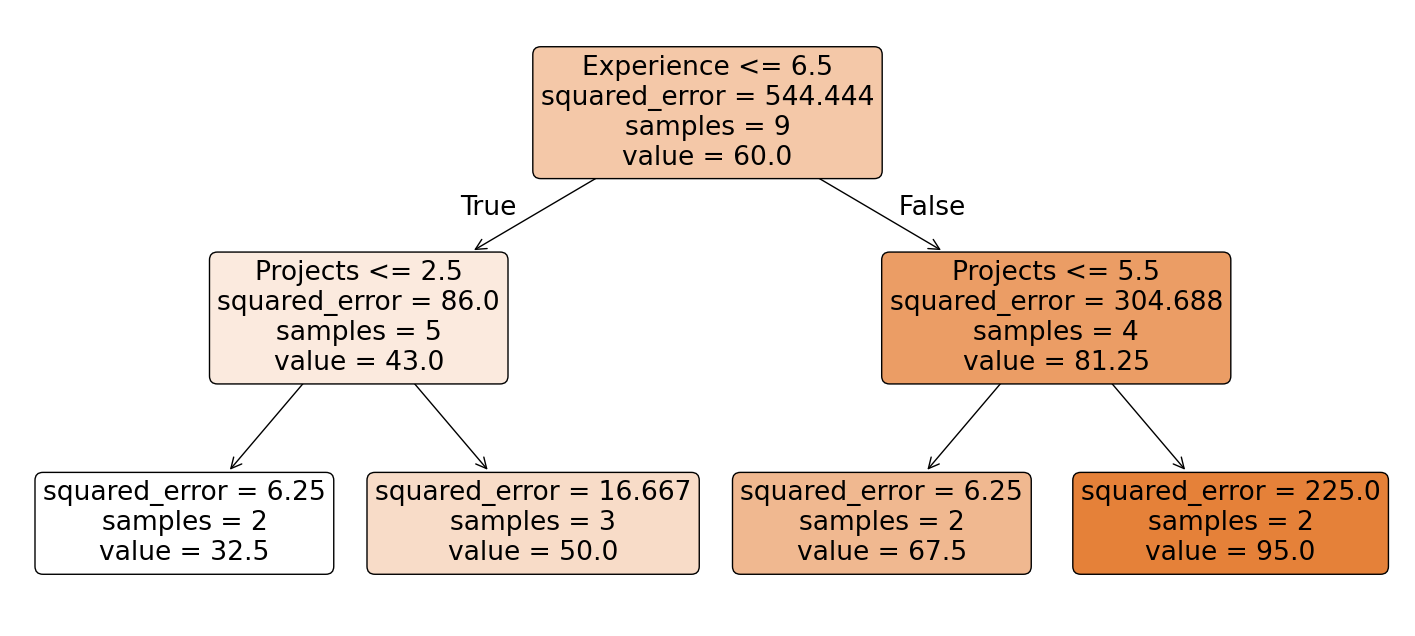

In [16]:
# Recreate and train the best model using the best_params found
best_model = DecisionTreeRegressor(
    max_depth=best_params['max_depth'],
    min_samples_split=best_params['min_samples_split'],
    min_samples_leaf=best_params['min_samples_leaf'],
    random_state=42
)
best_model.fit(X_train, y_train)

plt.figure(figsize=(18,8))

plot_tree(
    best_model,
    feature_names=['Experience', 'Projects'],
    filled=True,
    rounded=True
)

plt.show()


# 19. Key Learning Summary

## Decision Tree Regression Workflow

1. Create Dataset
2. Encode categorical data
3. Train model
4. Predict output
5. Evaluate performance
6. Tune hyperparameters
7. Compare tuned vs untuned model

---

## Important Hyperparameters

### **max_depth**: Controls depth of tree

### **min_samples_split**: Minimum samples required for split

### **min_samples_leaf**: Minimum samples required in leaf node

---

## Main Goal of Decision Tree Regression

**Reduce the variance** recursively until:
- nodes become pure
- stopping condition reached
